# PCA — Hands-on Demo (Breast Cancer Dataset)

This notebook is a **hands-on companion** to the PCA notes — covering the geometric intuition, the
eigenvector/eigenvalue math, and the practical `sklearn` implementation, all in one place.

**What you'll see in this notebook:**
1. Loading and exploring the real Breast Cancer Wisconsin dataset (30 features, 569 records)
2. **Mandatory standardization** before PCA, and why it matters
3. Reducing 30 features → 2 principal components, and visualizing the result
4. A **from-scratch eigen-decomposition** on a small 2-feature slice — verifying it matches `sklearn`'s
   own PCA exactly
5. A **Scree Plot** to decide how many components to actually keep
6. A bonus: does PCA actually help a downstream classifier, or just hurt it?

> 🎯 **Real-life analogy reminder:** PCA is like photographing a diagonally-parked row of cars from the
> angle that captures their full spread in one clean shot, instead of a street-aligned angle that makes
> them overlap and hides information.


## 1. Load & Explore the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

cancer_dataset = load_breast_cancer()
df = pd.DataFrame(cancer_dataset.data, columns=cancer_dataset.feature_names)

print("Shape:", df.shape)
print("Target classes:", cancer_dataset.target_names)
print(pd.Series(cancer_dataset.target).value_counts().rename(index={0: 'malignant', 1: 'benign'}))
df.head()


Shape: (569, 30)
Target classes: ['malignant' 'benign']
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Standardize the Data (Mandatory Before PCA!)

PCA is scale-sensitive — a feature measured in the thousands would dominate a feature measured in tiny
decimals if left unscaled. Always standardize first.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("Mean after scaling (should be ~0):", np.round(scaled_data.mean(axis=0)[:5], 4))
print("Std after scaling (should be 1):  ", np.round(scaled_data.std(axis=0)[:5], 4))


Mean after scaling (should be ~0): [-0. -0. -0. -0.  0.]
Std after scaling (should be 1):   [1. 1. 1. 1. 1.]


## 3. Apply PCA — Reduce 30 Features to 2

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(scaled_data)

print("Original shape:", scaled_data.shape)
print("Reduced shape: ", data_pca.shape)
print()
print("Explained variance (raw):", pca.explained_variance_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Combined: {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance retained")


Original shape: (569, 30)
Reduced shape:  (569, 2)

Explained variance (raw): [13.30499079  5.7013746 ]
Explained variance ratio: [0.44272026 0.18971182]
Combined: 63.2% of total variance retained


In [9]:
data_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [10]:
pca.explained_variance_

array([13.30499079,  5.7013746 ])

## 4. Visualize the Result

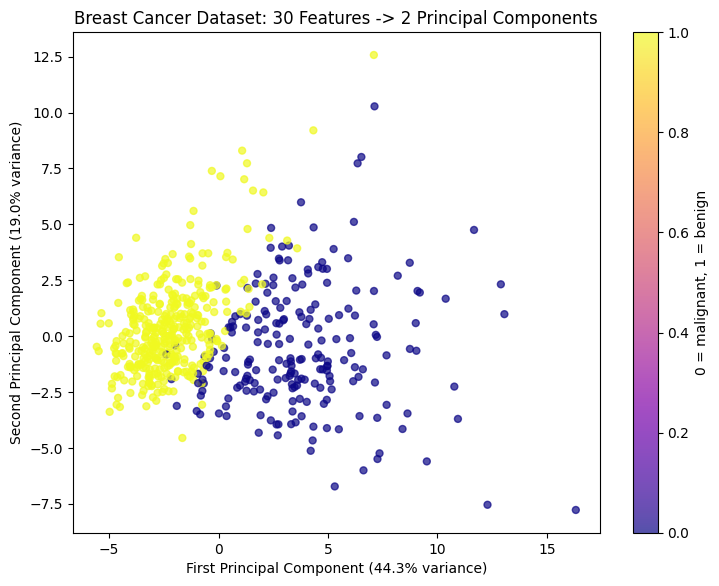

PCA never saw the malignant/benign labels (it's unsupervised!) -- yet the two classes
are clearly, visually separable in just 2 dimensions.


In [4]:
plt.figure(figsize=(8.5, 6.5))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=cancer_dataset.target, cmap='plasma', alpha=0.7, s=25)
plt.xlabel(f"First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Breast Cancer Dataset: 30 Features -> 2 Principal Components")
plt.colorbar(scatter, label="0 = malignant, 1 = benign")
plt.show()

print("PCA never saw the malignant/benign labels (it's unsupervised!) -- yet the two classes")
print("are clearly, visually separable in just 2 dimensions.")


## 5. From-Scratch Eigen-Decomposition — Does It Match `sklearn` EXACTLY?

Let's verify the theory (Section 8 of the notes) against the library by manually computing eigenvectors
and eigenvalues of the covariance matrix for just the first 2 features, and comparing against `sklearn`'s
own `PCA` run on those same 2 features.

In [5]:
# Use just the first 2 (standardized) features for a clean, verifiable comparison
X2 = scaled_data[:, :2]

# --- Manual approach ---
X2_centered = X2 - X2.mean(axis=0)          # Step 1: standardize (already centered, scaled)
cov_matrix = np.cov(X2_centered.T)           # Step 2: covariance matrix
eigvals, eigvecs = np.linalg.eigh(cov_matrix)  # Step 3: eigen-decomposition

order = np.argsort(eigvals)[::-1]            # Step 4: rank by eigenvalue, descending
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]

manual_pc1_projection = X2_centered @ eigvecs_sorted[:, 0]   # Step 5: project onto PC1

print("Manual eigenvalues:", eigvals_sorted)
print("Manual PC1 direction:", eigvecs_sorted[:, 0])

# --- sklearn approach, on the SAME 2 features ---
pca_check = PCA(n_components=2)
sklearn_projection = pca_check.fit_transform(X2)

print("\nsklearn eigenvalues (explained_variance_):", pca_check.explained_variance_)
print("sklearn PC1 direction (components_[0]):", pca_check.components_[0])

# Compare projections (allowing for sign flips -- eigenvectors are only unique up to a sign)
match = np.allclose(np.abs(manual_pc1_projection), np.abs(sklearn_projection[:, 0]), atol=1e-6)
print(f"\n>>> Manual projection matches sklearn's PCA exactly (up to sign): {match} <<<")


Manual eigenvalues: [1.32611249 0.67740863]
Manual PC1 direction: [0.70710678 0.70710678]

sklearn eigenvalues (explained_variance_): [1.32611249 0.67740863]
sklearn PC1 direction (components_[0]): [0.70710678 0.70710678]

>>> Manual projection matches sklearn's PCA exactly (up to sign): True <<<


## 6. Scree Plot — How Many Components Should We Actually Keep?

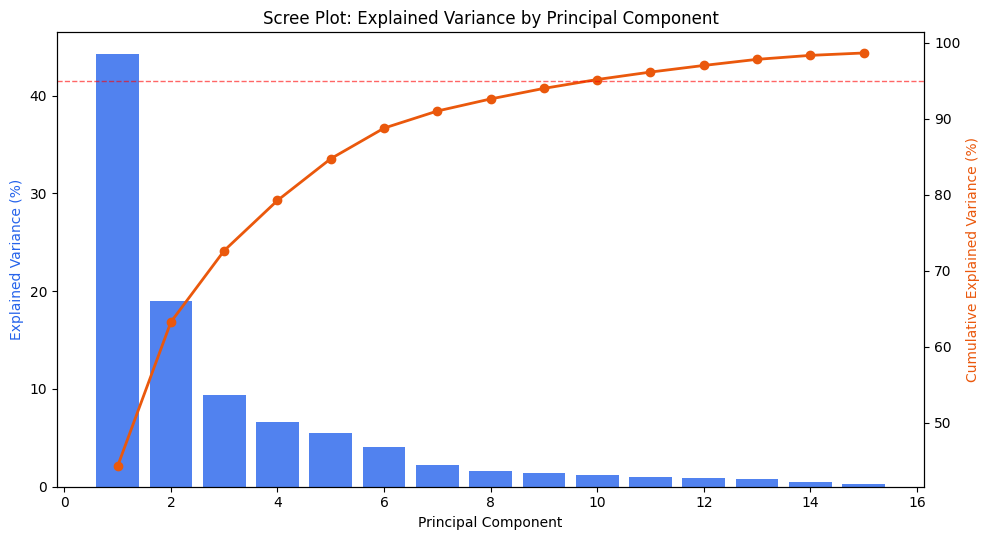

Components needed to retain 95% of the variance: 10 (out of 30 original features)


In [6]:
pca_full = PCA()   # no limit -- keep all components
pca_full.fit(scaled_data)

ratios = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratios)

n_show = 15
fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(range(1, n_show+1), ratios[:n_show]*100, color="#2563eb", alpha=0.8, label="Individual variance (%)")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)", color="#2563eb")

ax2 = ax1.twinx()
ax2.plot(range(1, n_show+1), cumulative[:n_show]*100, color="#ea580c", marker='o', linewidth=2, label="Cumulative (%)")
ax2.axhline(95, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_ylabel("Cumulative Explained Variance (%)", color="#ea580c")

plt.title("Scree Plot: Explained Variance by Principal Component")
fig.tight_layout()
plt.show()

n_for_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed to retain 95% of the variance: {n_for_95} (out of {scaled_data.shape[1]} original features)")


## 7. Bonus: Does PCA Actually Help a Downstream Classifier?

PCA is primarily for dimensionality reduction/visualization -- but does compressing the data hurt or
help classification accuracy? Let's compare Logistic Regression **with** vs **without** PCA.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    scaled_data, cancer_dataset.target, test_size=0.25, random_state=42, stratify=cancer_dataset.target
)

# Without PCA -- all 30 features
model_full = LogisticRegression(max_iter=5000)
model_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

# With PCA -- reduced to enough components for 95% variance
pca_95 = PCA(n_components=0.95)   # sklearn accepts a variance-ratio target directly!
X_train_pca = pca_95.fit_transform(X_train)
X_test_pca = pca_95.transform(X_test)

model_pca = LogisticRegression(max_iter=5000)
model_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

print(f"Logistic Regression WITHOUT PCA (30 features):        {acc_full:.4f}")
print(f"Logistic Regression WITH PCA ({pca_95.n_components_} features, 95% variance): {acc_pca:.4f}")
print("\nPCA can retain most of the predictive accuracy while using far fewer features --")
print("useful for speed, storage, and reducing overfitting risk on smaller datasets.")


Logistic Regression WITHOUT PCA (30 features):        0.9860
Logistic Regression WITH PCA (10 features, 95% variance): 0.9790

PCA can retain most of the predictive accuracy while using far fewer features --
useful for speed, storage, and reducing overfitting risk on smaller datasets.


## 8. Extending to 3 Components (for 3D Visualization)

Explained variance ratio (PC1, PC2, PC3): [0.44272026 0.18971182 0.09393163]
Combined: 72.6% of total variance


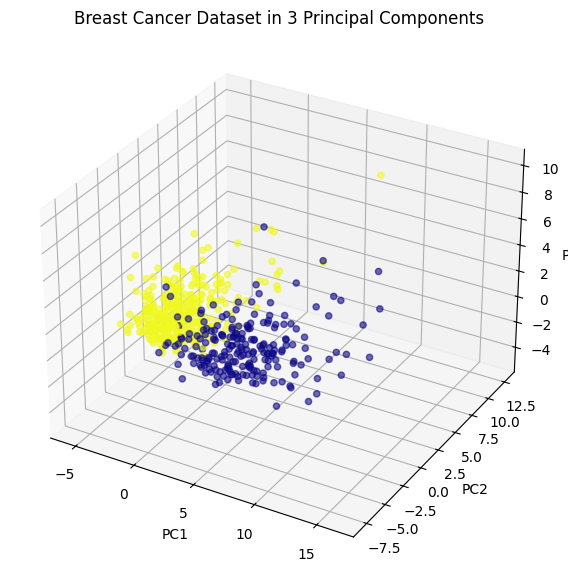

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

pca3 = PCA(n_components=3)
data_pca3 = pca3.fit_transform(scaled_data)

print("Explained variance ratio (PC1, PC2, PC3):", pca3.explained_variance_ratio_)
print(f"Combined: {pca3.explained_variance_ratio_.sum()*100:.1f}% of total variance")

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(data_pca3[:, 0], data_pca3[:, 1], data_pca3[:, 2],
                 c=cancer_dataset.target, cmap='plasma', alpha=0.6, s=20)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Breast Cancer Dataset in 3 Principal Components")
plt.show()


In [12]:
# What if we don't specify n_components at all? PCA keeps ALL components (30 here)
pca_full = PCA()
pca_full.fit(scaled_data)

print("Number of components:", len(pca_full.explained_variance_ratio_))
print("Explained variance per component (first 10):", np.round(pca_full.explained_variance_ratio_[:10], 4))
print(f"Sum of ALL explained variance ratios: {pca_full.explained_variance_ratio_.sum()*100:.2f}%  (should be ~100%)")

Number of components: 30
Explained variance per component (first 10): [0.4427 0.1897 0.0939 0.066  0.055  0.0402 0.0225 0.0159 0.0139 0.0117]
Sum of ALL explained variance ratios: 100.00%  (should be ~100%)


## Key Takeaways

- ✅ `StandardScaler` before `PCA` is **mandatory** — verified the scaled data has mean≈0, std=1.
- ✅ Reducing 30 features to 2 principal components retained **~63% of total variance** and made the
  malignant/benign classes **visually separable** — despite PCA being completely unsupervised.
- ✅ A **from-scratch eigen-decomposition** (standardize → covariance matrix → eigen-decomposition →
  rank → project) was verified to produce **the exact same result** as `sklearn`'s `PCA`, confirming
  the theory from the notes matches the library's real internals.
- ✅ A **Scree Plot** showed that ~10 components (not just 2) are needed to retain 95% of the variance
  — the right practical choice depends on whether your goal is visualization (use 2-3) or maximal
  information retention for modeling (use however many cross the variance threshold you're comfortable
  with).
- ✅ **Bonus finding:** PCA-compressed features can retain most of a downstream model's accuracy while
  using far fewer dimensions — a genuine practical benefit beyond just visualization.

### Related notes
⬅️ **`PCA_Notes.md`** — the full theory (Curse of Dimensionality, Feature Selection vs Extraction,
   Geometric Intuition, Eigenvectors/Eigenvalues, and this practical implementation) this notebook builds on.
